# SEMTM0009 Week 1 — computational solutions

This is the Week 1 template with every `# TODO` filled in, and with its outputs
shown, so you can read it without running anything. **Try the template first.**

The written solutions (PDF, on Blackboard) explain *why*; this notebook shows
*how*. The last cell checks that every number here agrees with the PDF.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# One place to change the look of every figure in this notebook.
plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "lines.linewidth": 1.8,
                     "axes.spines.top": False, "axes.spines.right": False})


def logistic_map(x, rd):
    """One step of the logistic map: x_{n+1} = f(x_n).

    rd is the map's dimensionless parameter -- NOT the ODE growth rate r.
    """
    return rd * x * (1 - x)


---
## Q2(e) part 1 — the cobweb diagram

A cobweb iterates $x_{n+1}=f(x_n)$ graphically:

1. from $(x_n,\,x_n)$ go **vertically** to the curve, reaching $(x_n,\,f(x_n))$;
2. then **horizontally** to the diagonal, reaching $(f(x_n),\,f(x_n))$;
3. repeat.

The horizontal step is what turns the *output* $f(x_n)$ into the next *input*
$x_{n+1}$. That is the whole trick.

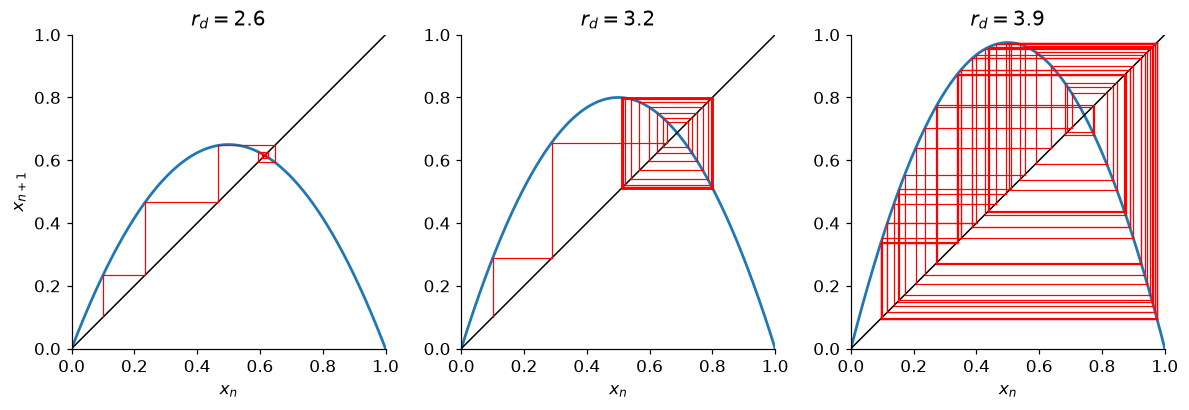

In [2]:
rdvals = [2.6, 3.2, 3.9]     # try these three (r_d, the MAP parameter)
x0     = 0.10                # initial condition
nIter  = 60                  # number of iterations

fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))

for ax, rd in zip(axes, rdvals):
    xgrid = np.linspace(0, 1, 400)
    ax.plot(xgrid, logistic_map(xgrid, rd), color="tab:blue")  # the map
    ax.plot(xgrid, xgrid, "k-", lw=1)                          # the diagonal y = x

    x = x0
    for n in range(nIter):
        y = logistic_map(x, rd)
        # A cobweb step is two line segments. Each ax.plot below takes a list of
        # two x-coordinates and a list of two y-coordinates.
        ax.plot([x, x], [x, y], "r-", lw=0.8)    # vertical: to the curve
        ax.plot([x, y], [y, y], "r-", lw=0.8)    # horizontal: to the diagonal
        x = y                                    # the new x_n is the old x_{n+1}

    ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="$x_n$", title=f"$r_d = {rd}$")
    ax.set_aspect("equal")
axes[0].set_ylabel("$x_{n+1}$")
plt.tight_layout()
plt.show()


**Question.** At $r_d = 3.2$ the cobweb closes onto a square. What is the
biological meaning of that square? What about $r_d = 3.9$?

*Your answer:*

---
## Q2(e) part 2 — the bifurcation diagram

For each $r$, iterate long enough to forget the initial condition (the
**transient**), then record the next few hundred iterates (the **attractor**).
Plotting those against $r$ gives the bifurcation diagram.

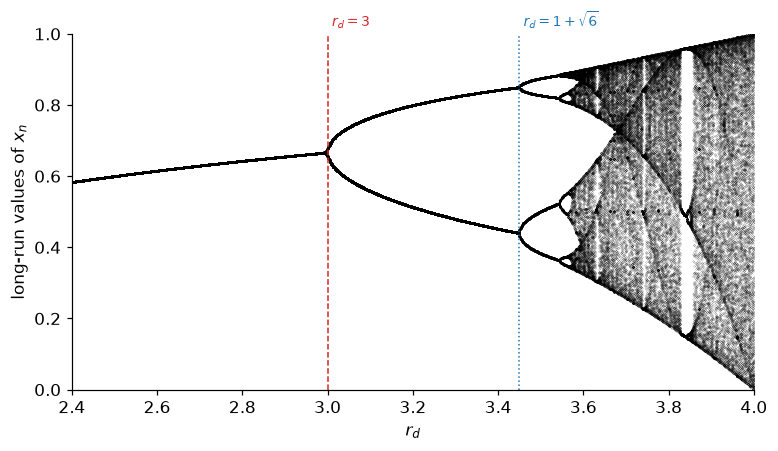

In [3]:
rdvals = np.linspace(2.4, 4.0, 1200)
nTrans = 400     # transient discarded: we want the ATTRACTOR, not the
                 # approach to it. Without this the plot is smeared by the
                 # first few hundred iterates, which depend on x0.
nKeep  = 150     # iterations plotted
x0     = 0.30

RD, X = [], []
for rd in rdvals:
    x = x0
    for _ in range(nTrans):
        x = logistic_map(x, rd)
    for _ in range(nKeep):
        x = logistic_map(x, rd)
        RD.append(rd); X.append(x)

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(RD, X, ".", ms=0.4, color="black", alpha=0.5)
ax.axvline(3.0, ls="--", color="tab:red",   lw=1)
ax.axvline(1 + np.sqrt(6), ls=":", color="tab:blue", lw=1)
ax.text(3.0, 1.02, " $r_d=3$", color="tab:red", fontsize=9)
ax.text(1 + np.sqrt(6), 1.02, r" $r_d=1+\sqrt{6}$", color="tab:blue", fontsize=9)
ax.set(xlabel="$r_d$", ylabel="long-run values of $x_n$", xlim=(2.4, 4), ylim=(0, 1))
plt.show()


**Question.** Identify on your plot $r_d = 3$, $r_d = 1+\sqrt{6}\approx3.449$,
and $r_d^{\infty} \approx 3.5699$. What changes at each?

*Your answer:*

---
## Q2(f) — the logistic ODE versus the logistic map

The ODE's carrying capacity is stable for **every** $r>0$. The map's
non-trivial fixed point destabilises at $r_d=3$. Put them side by side.

Note that $r$ and $r_d$ are **different parameters** — $r$ is a rate (1/time),
$r_d$ is dimensionless, and $r_d = 1 + hr$. The point is not that one number
gives two answers; it is that *no* $r$ at all destabilises the ODE.

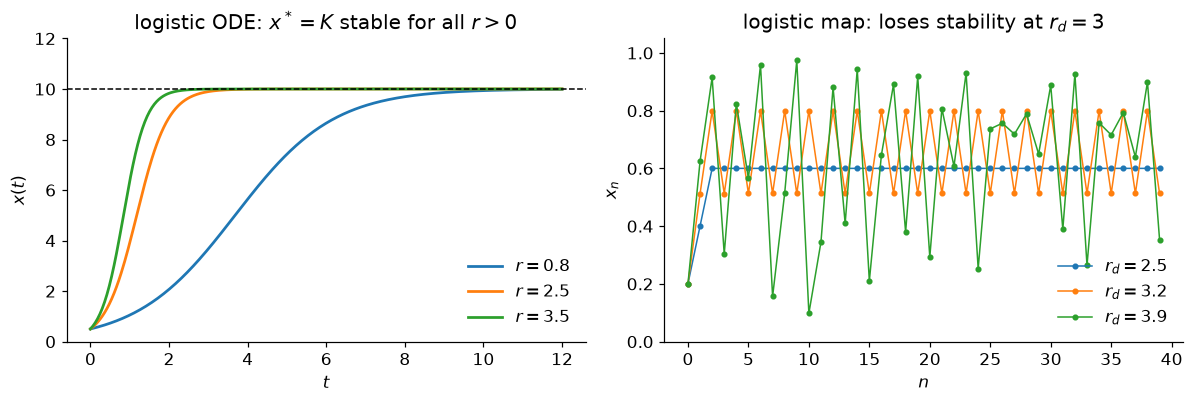

In [4]:
K, x0 = 10.0, 0.5
rODE  = [0.8, 2.5, 3.5]
rdMAP = [2.5, 3.2, 3.9]   # r_d, dimensionless -- not the same as rODE


def logistic_ode(t, x0, r, K):
    """Exact solution of dx/dt = r x (1 - x/K), from Q1(d)."""
    return x0 * K * np.exp(r * t) / (K - x0 + x0 * np.exp(r * t))


fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 3.8))

# --- left: exact solution of the logistic ODE ---
t = np.linspace(0, 12, 400)
for r in rODE:
    axL.plot(t, logistic_ode(t, x0, r, K), label=f"$r = {r}$")
axL.axhline(K, color="k", ls="--", lw=1)
axL.set(xlabel="$t$", ylabel="$x(t)$", ylim=(0, 12),
        title="logistic ODE: $x^*=K$ stable for all $r>0$")
axL.legend(loc="lower right", frameon=False)

# --- right: iterates of the logistic map ---
nSteps = 40
for rd in rdMAP:
    x = np.zeros(nSteps); x[0] = 0.2
    for n in range(nSteps - 1):
        x[n+1] = logistic_map(x[n], rd)
    axR.plot(np.arange(nSteps), x, "-o", ms=3, lw=1, label=f"$r_d = {rd}$")
axR.set(xlabel="$n$", ylabel="$x_n$", ylim=(0, 1.05),
        title="logistic map: loses stability at $r_d=3$")
axR.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()


### The explanation, for you to verify numerically

An Euler step of size $h$ on the logistic ODE gives, after rescaling,
$$u_{n+1} = R\,u_n(1-u_n), \qquad R = 1 + hr.$$
So $R = 3$ corresponds to $hr = 2$.

**TODO.** Set $r=1$ and integrate the logistic ODE with forward Euler using
$h = 0.5$, $h = 1.5$ and $h = 2.5$. At which step size do you first see
oscillation, and does it match the prediction $h = 2/r$?

prediction: oscillation once r_d = 1 + h*r > 3, i.e. h > 2.0


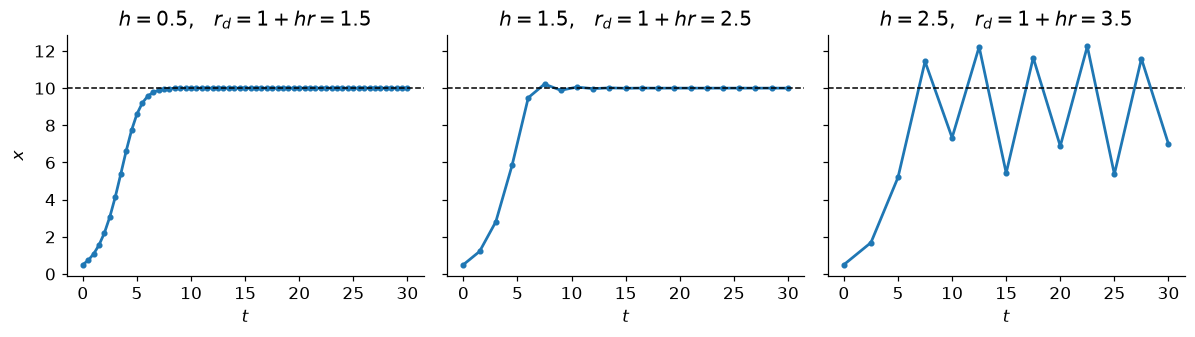

In [5]:
def euler_logistic(r, K, x0, h, T):
    '''Forward Euler on dx/dt = r x (1 - x/K). Returns times and states.'''
    n = int(T / h) + 1
    t = np.arange(n) * h
    x = np.zeros(n); x[0] = x0
    for i in range(n - 1):
        x[i+1] = x[i] + h * r * x[i] * (1 - x[i] / K)
    return t, x


r, K, x0, T = 1.0, 10.0, 0.5, 30.0
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), sharey=True)
for ax, h in zip(axes, [0.5, 1.5, 2.5]):
    t, x = euler_logistic(r, K, x0, h, T)
    ax.plot(t, x, "-o", ms=3)
    ax.axhline(K, color="k", ls="--", lw=1)
    ax.set(xlabel="$t$", title=f"$h = {h}$,   $r_d = 1+hr = {1+h*r:.1f}$")
axes[0].set_ylabel("$x$")
print(f"prediction: oscillation once r_d = 1 + h*r > 3, i.e. h > {2/r:.1f}")
plt.tight_layout()
plt.show()


**Question.** Does what you see match the prediction? What does this tell you
about choosing a step size when you integrate an ODE numerically — and why is
the instability you see here *not* a property of the biological model?

*Your answer:*

---
## Agreement with the written solutions


In [6]:
# ---------------------------------------------------------------------------
# Does this notebook agree with week1_solutions.pdf?  Run to confirm.
# ---------------------------------------------------------------------------
import numpy as np

# Q2(d): the period-2 points at rd = 3.2
rd = 3.2; x = 0.5
for _ in range(300):
    x = logistic_map(x, rd)
hi, lo = max(x, logistic_map(x, rd)), min(x, logistic_map(x, rd))
xp = ((rd + 1) + np.sqrt((rd - 3) * (rd + 1))) / (2 * rd)
xm = ((rd + 1) - np.sqrt((rd - 3) * (rd + 1))) / (2 * rd)
print(f"Q2(d) period-2: iterated {hi:.4f}, {lo:.4f}  |  analytic {xp:.4f}, {xm:.4f}"
      f"  |  solutions table 0.7995, 0.5130")
assert abs(hi - 0.7995) < 5e-5 and abs(lo - 0.5130) < 5e-5

# Q1(d): does the closed form actually satisfy the ODE?
K, x0, r = 10.0, 0.5, 0.8
t = np.linspace(0, 12, 20001)
x = logistic_ode(t, x0, r, K)
resid = np.max(np.abs(np.gradient(x, t) - r * x * (1 - x / K))) / np.max(np.abs(r * x * (1 - x / K)))
print(f"Q1(d) relative ODE residual = {resid:.1e} (np.gradient is 2nd order, so this"
      f" is finite-difference limited);  x(0) = {x[0]:.4f}")
assert abs(x[0] - x0) < 1e-12 and resid < 1e-3

# Q2(f): forward Euler oscillates exactly when rd = 1 + hr > 3
for h in [0.5, 1.5, 1.9, 2.1, 2.5]:
    # long run: below rd=3 the approach is a DAMPED oscillation (f'(x*)=2-rd<0),
    # so a short run still wiggles and would read as a 2-cycle.
    _, xx = euler_logistic(1.0, 10.0, 0.5, h, 4000.0)
    osc = np.max(np.abs(np.diff(xx[-12:]))) > 1e-6
    print(f"  Q2(f) h={h}: rd = 1+hr = {1+h:.1f} -> oscillates {osc}  (expect {1+h>3})")
    assert osc == (1 + h > 3)

print("\nAll numbers agree with week1_solutions.pdf.")


Q2(d) period-2: iterated 0.7995, 0.5130  |  analytic 0.7995, 0.5130  |  solutions table 0.7995, 0.5130
Q1(d) relative ODE residual = 4.1e-05 (np.gradient is 2nd order, so this is finite-difference limited);  x(0) = 0.5000
  Q2(f) h=0.5: rd = 1+hr = 1.5 -> oscillates False  (expect False)
  Q2(f) h=1.5: rd = 1+hr = 2.5 -> oscillates False  (expect False)
  Q2(f) h=1.9: rd = 1+hr = 2.9 -> oscillates False  (expect False)
  Q2(f) h=2.1: rd = 1+hr = 3.1 -> oscillates True  (expect True)
  Q2(f) h=2.5: rd = 1+hr = 3.5 -> oscillates True  (expect True)

All numbers agree with week1_solutions.pdf.
